# 08F – Cross-Validation & Stability Analysis

Enterprise notebook to evaluate the stability and consistency of the bankruptcy prediction model across multiple folds.

## Business Objective
Validate that model performance is consistent across different data splits and quantify performance variability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

In [2]:
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'

df=pd.read_csv(DATA_PATH)

if 'status_label' in df.columns:
    y=df['status_label'].map({'alive':0,'failed':1})
    X=df.drop(columns=[col for col in ['status_label','company_name'] if col in df.columns])
elif 'target' in df.columns:
    y=df['target']
    X=df.drop(columns=[col for col in ['target','company_name'] if col in df.columns])
else:
    raise ValueError('Target column not found')


In [3]:
# Match production model configuration
model=RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=1
)

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Subsample so 5-fold CV finishes quickly on a single core.
CV_SAMPLE_SIZE = 20000
if len(X) > CV_SAMPLE_SIZE:
    X_cv = X.sample(n=CV_SAMPLE_SIZE, random_state=42)
    y_cv = y.loc[X_cv.index]
else:
    X_cv, y_cv = X, y

scores=cross_validate(
    model,
    X_cv,
    y_cv,
    cv=cv,
    scoring=['accuracy','precision','recall','f1','roc_auc'],
    return_train_score=False,
    n_jobs=1
)


In [4]:
results=pd.DataFrame({
    'Fold':range(1,6),
    'Accuracy':scores['test_accuracy'],
    'Precision':scores['test_precision'],
    'Recall':scores['test_recall'],
    'F1':scores['test_f1'],
    'ROC_AUC':scores['test_roc_auc']
})

summary=results.describe().T[['mean','std','min','max']]
results.to_csv('cross_validation_scores.csv',index=False)
summary.to_csv('cross_validation_summary.csv')

display(results)
display(summary)


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.91550,0.322581,0.220588,0.262009,0.793336
1,2,0.90300,0.215686,0.161765,0.184874,0.771224
2,3,0.90750,0.262136,0.198529,0.225941,0.773020
3,4,0.89275,0.201521,0.194853,0.198131,0.765069
4,5,0.91075,0.276596,0.190476,0.225597,0.778928


,mean,std,min,max
Fold,3.000000,1.581139,1.000000,5.000000
Accuracy,0.905900,0.008654,0.892750,0.915500
Precision,0.255704,0.048702,0.201521,0.322581
Recall,0.193242,0.021076,0.161765,0.220588
F1,0.219310,0.029753,0.184874,0.262009
ROC_AUC,0.776315,0.010721,0.765069,0.793336


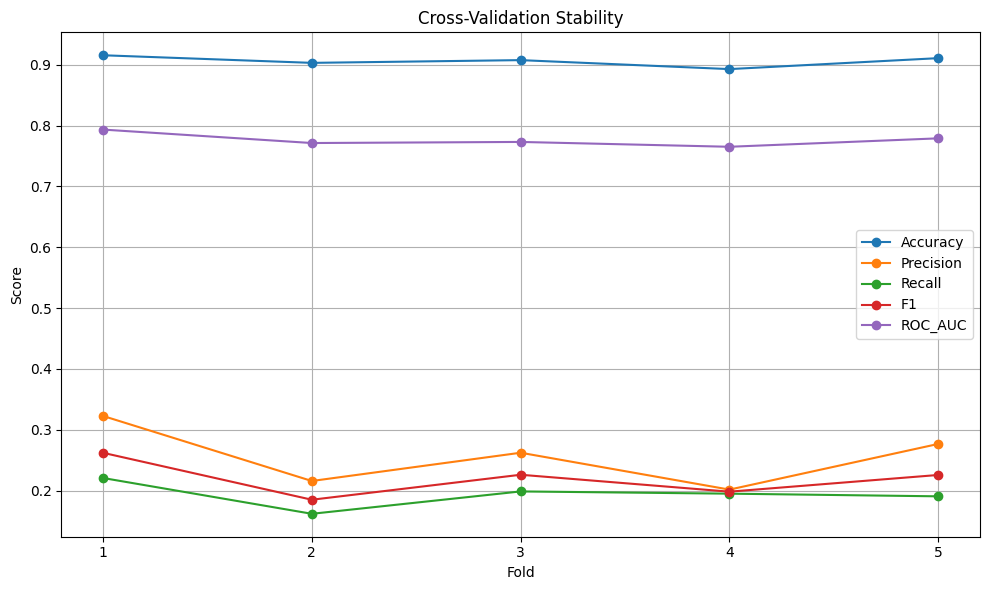

In [5]:
plt.figure(figsize=(10,6))
for metric in ['Accuracy','Precision','Recall','F1','ROC_AUC']:
    plt.plot(results['Fold'],results[metric],marker='o',label=metric)

plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Cross-Validation Stability')
plt.xticks(results['Fold'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('cross_validation_stability.png',dpi=300)
plt.show()

## Business Interpretation

- Low standard deviation across folds indicates a stable and reliable model.
- Large variation suggests the model is sensitive to data splits and may require additional tuning or more representative data.
- Consistent ROC-AUC and F1 scores strengthen confidence in production deployment.

## Deliverables

- `cross_validation_scores.csv`
- `cross_validation_summary.csv`
- `cross_validation_stability.png`

This notebook demonstrates that the reported performance is reproducible and not dependent on a single train/test split.